#  Revenue Forecasting – Technical Report

## 1. Problem Overview

Mục tiêu: dự báo **Revenue theo ngày** cho e-commerce thời trang.

Dữ liệu:
- `sales.csv` (Revenue, COGS)
- `orders.csv`
- `web_traffic.csv`

Pipeline:
- Feature Engineering (time + behavior)
- Proxy lịch sử (2021–2022)
- Time-based validation
- Ensemble (LGB, XGB, CatBoost)

**Constraints:**
- Không dùng dữ liệu ngoài  
- Không dùng Revenue/COGS test làm feature  
- Cố định seed → reproducible  

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")

## 2. Data Preparation

- Load dữ liệu và chuẩn hóa datetime
- Tạo timeline liên tục để học pattern đầy đủ

In [2]:
input_dir = "/kaggle/input/competitions"
competition_folder = os.listdir(input_dir)[0] 
base_path = os.path.join(input_dir, competition_folder) + "/"

sales_df = pd.read_csv(base_path + "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(base_path + "orders.csv", parse_dates=["order_date"])
web = pd.read_csv(base_path + "web_traffic.csv", parse_dates=["date"])

## 3. Feature Engineering – Time & Seasonality

Tạo:
- Calendar features (month, dayofweek…)
- Event features (weekend, payday, double-day)
- Distance features

-> Không leakage vì chỉ dùng thông tin hiện tại

In [3]:
# =========================================
# 2. TIME FEATURES & MICRO-SEASONALITY
# =========================================
full_dates = pd.DataFrame({'Date': pd.date_range(start=sales_df.Date.min(), end=pd.to_datetime("2024-07-01"))})
df = full_dates.merge(sales_df[['Date','Revenue','COGS']], on='Date', how='left')

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['quarter'] = df['Date'].dt.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

df['dayofyear'] = df['Date'].dt.dayofyear
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['Date'].dt.is_quarter_start.astype(int)
df['is_quarter_end'] = df['Date'].dt.is_quarter_end.astype(int)

df['is_double_day'] = (df['month'] == df['day']).astype(int)
df['is_payday'] = df['day'].isin([1, 5, 15, 25]).astype(int)

df['next_double_day'] = df['Date'].where(df['is_double_day'] == 1).bfill()
df['prev_double_day'] = df['Date'].where(df['is_double_day'] == 1).ffill()
df['days_to_next_double'] = (df['next_double_day'] - df['Date']).dt.days.fillna(30).clip(upper=30)
df['days_since_prev_double'] = (df['Date'] - df['prev_double_day']).dt.days.fillna(30).clip(upper=30)
df.drop(columns=['next_double_day', 'prev_double_day'], inplace=True)


## 4. External Signals

Thêm:
- Orders → nhu cầu thực
- Web traffic → hành vi user

-> Là leading indicators của Revenue

In [4]:
# =========================================
# 3. CHUẨN BỊ DỮ LIỆU NGOÀI
# =========================================
orders['date_only'] = orders['order_date'].dt.date
daily_orders = orders.groupby('date_only').size().reset_index(name='orders_count')
daily_orders['date_only'] = pd.to_datetime(daily_orders['date_only'])
df = df.merge(daily_orders, left_on='Date', right_on='date_only', how='left').drop(columns=['date_only'])

web.rename(columns={'date':'Date'}, inplace=True)
df = df.merge(web[['Date','sessions','unique_visitors','page_views','bounce_rate']], on='Date', how='left')


## 5. Proxy Features (2021–2022)

Tạo median theo:
- month + dayofweek
- day
- week

Vai trò:
- “memory” của mô hình
- capture pattern lặp lại

Chỉ dùng ≤ 2022 → không leakage

In [5]:
# =========================================
# 4. RECENT MEDIAN PROXIES (2021-2022)
# =========================================
recent_train_mask = (df['Date'] >= '2021-01-01') & (df['Date'] <= '2022-12-31')
proxy_cols = ['orders_count', 'sessions', 'page_views', 'bounce_rate', 'Revenue']

prof_m_dow = df[recent_train_mask].groupby(['month', 'dayofweek'])[proxy_cols].median().reset_index()
prof_m_dow.columns = ['month', 'dayofweek'] + [f"proxy_{c}_m_dow" for c in proxy_cols]
df = df.merge(prof_m_dow, on=['month', 'dayofweek'], how='left')

prof_day = df[recent_train_mask].groupby(['day'])[proxy_cols].median().reset_index()
prof_day.columns = ['day'] + [f"proxy_{c}_day" for c in proxy_cols]
df = df.merge(prof_day, on=['day'], how='left')

prof_week = df[recent_train_mask].groupby(['weekofyear'])[proxy_cols].median().reset_index()
prof_week.columns = ['weekofyear'] + [f"proxy_{c}_week" for c in proxy_cols]
df = df.merge(prof_week, on=['weekofyear'], how='left')

for c in df.columns:
    if 'proxy_' in c:
        df[c] = df[c].fillna(df[recent_train_mask][c.replace('proxy_', '').replace('_m_dow','').replace('_day','').replace('_week','')].median())


## 6. Time-based Split & Training

Split:
- Train: ≤ 2021
- Validation: 2022
- Test: ≥ 2023

Model:
- LightGBM
- XGBoost
- CatBoost

Technique:
- Seed averaging
- Ensemble

-> Giảm variance + tăng stability

In [6]:
# =========================================
# 5. SPLIT DỮ LIỆU & HUẤN LUYỆN
# =========================================
features = [
    'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear',
    'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
    'is_double_day', 'is_payday', 'days_to_next_double', 'days_since_prev_double',
    'proxy_orders_count_m_dow', 'proxy_sessions_m_dow', 'proxy_page_views_m_dow', 'proxy_bounce_rate_m_dow', 'proxy_Revenue_m_dow',
    'proxy_orders_count_day', 'proxy_sessions_day', 'proxy_page_views_day', 'proxy_bounce_rate_day', 'proxy_Revenue_day',
    'proxy_orders_count_week', 'proxy_sessions_week', 'proxy_page_views_week', 'proxy_bounce_rate_week', 'proxy_Revenue_week'
]

# Validation Set: Dùng toàn bộ lịch sử đến 2021 làm Train, test trên 2022
val_train_df = df[df['Date'] <= '2021-12-31'].copy()
val_df       = df[(df['Date'] >= '2022-01-01') & (df['Date'] <= '2022-12-31')].copy()

X_val_train = val_train_df[features]
y_val_train = val_train_df['Revenue']  
X_val       = val_df[features]
y_val_true  = val_df['Revenue']

# Full Train Set
full_train_df = df[df['Date'] <= '2022-12-31'].copy()
test_df       = df[df['Date'] >= '2023-01-01'].copy()

X_full = full_train_df[features]
y_full = full_train_df['Revenue'] 
X_test = test_df[features]

# Khởi tạo ma trận chứa dự báo
SEED_LIST = [42, 2026, 8888, 777, 999]
preds_val_lgb, preds_val_xgb, preds_val_cb = np.zeros(len(X_val)), np.zeros(len(X_val)), np.zeros(len(X_val))
preds_test_lgb, preds_test_xgb, preds_test_cb = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
lgb_importance = np.zeros(len(features))

print(f"Đang tiến hành Seed Averaging với {len(SEED_LIST)} seed")

for seed in SEED_LIST:
    print(f"--- Đang huấn luyện bộ mô hình với Seed: {seed} ---")
    
    # ------------------ LightGBM ------------------
    model_lgb = lgb.LGBMRegressor(
        objective='mae', n_estimators=800, learning_rate=0.012, max_depth=7, num_leaves=45,
        subsample=0.8, colsample_bytree=0.8, random_state=seed, n_jobs=-1, verbose=-1
    )
    # Train 1: Đánh giá Validation
    model_lgb.fit(X_val_train, y_val_train)
    preds_val_lgb += model_lgb.predict(X_val) / len(SEED_LIST)
    # Train 2: Dự báo Kaggle Test
    model_lgb.fit(X_full, y_full)
    preds_test_lgb += model_lgb.predict(X_test) / len(SEED_LIST)
    lgb_importance += model_lgb.feature_importances_ / len(SEED_LIST)
    
    # ------------------ XGBoost ------------------
    model_xgb = xgb.XGBRegressor(
        objective='reg:absoluteerror', n_estimators=800, learning_rate=0.012, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=seed, n_jobs=-1, verbosity=0
    )
    model_xgb.fit(X_val_train, y_val_train)
    preds_val_xgb += model_xgb.predict(X_val) / len(SEED_LIST)
    
    model_xgb.fit(X_full, y_full)
    preds_test_xgb += model_xgb.predict(X_test) / len(SEED_LIST)
    
    # ------------------ CatBoost ------------------
    model_cb = CatBoostRegressor(
        loss_function='MAE', iterations=850, learning_rate=0.015, depth=6,
        subsample=0.8, random_seed=seed, verbose=False
    )
    model_cb.fit(X_val_train, y_val_train)
    preds_val_cb += model_cb.predict(X_val) / len(SEED_LIST)
    
    model_cb.fit(X_full, y_full)
    preds_test_cb += model_cb.predict(X_test) / len(SEED_LIST)


Đang tiến hành Seed Averaging với 5 seed
--- Đang huấn luyện bộ mô hình với Seed: 42 ---
--- Đang huấn luyện bộ mô hình với Seed: 2026 ---
--- Đang huấn luyện bộ mô hình với Seed: 8888 ---
--- Đang huấn luyện bộ mô hình với Seed: 777 ---
--- Đang huấn luyện bộ mô hình với Seed: 999 ---


## 7. Evaluation

Đánh giá trên năm 2022:
- MAE
- RMSE
- R²

-> Đảm bảo mô hình không dùng tương lai

In [7]:
# =========================================
# 5.1 XUẤT CHỈ SỐ ĐÁNH GIÁ (VALIDATION) & FEATURE IMPORTANCE
# =========================================
pred_val_final = (preds_val_lgb * 0.40) + (preds_val_xgb * 0.20) + (preds_val_cb * 0.40)

mae_val = mean_absolute_error(y_val_true, pred_val_final)
rmse_val = np.sqrt(mean_squared_error(y_val_true, pred_val_final))
r2_val = r2_score(y_val_true, pred_val_final)

print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION (NĂM 2022)")
print(f"MAE  : {mae_val:,.4f}")
print(f"RMSE : {rmse_val:,.4f}")
print(f"R^2  : {r2_val:.4f}")


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION (NĂM 2022)
MAE  : 1,426,287.0337
RMSE : 1,788,493.4788
R^2  : -0.1417


## 8. Model Explainability

Sử dụng:
- Feature Importance → global
- SHAP → directional

-> Hiểu model + chuyển thành insight kinh doanh


TOP 15 FEATURES THEO LIGHTGBM FEATURE IMPORTANCE
                 feature  importance
 proxy_bounce_rate_m_dow      2325.8
               dayofyear      2069.4
     proxy_Revenue_m_dow      1969.8
     days_to_next_double      1908.2
  days_since_prev_double      1896.8
  proxy_page_views_m_dow      1859.0
proxy_orders_count_m_dow      1838.2
    proxy_sessions_m_dow      1742.0
      proxy_sessions_day      1594.0
    proxy_page_views_day      1592.6
  proxy_orders_count_day      1584.6
                     day      1580.2
   proxy_bounce_rate_day      1504.6
               dayofweek      1359.0
      proxy_Revenue_week      1106.2


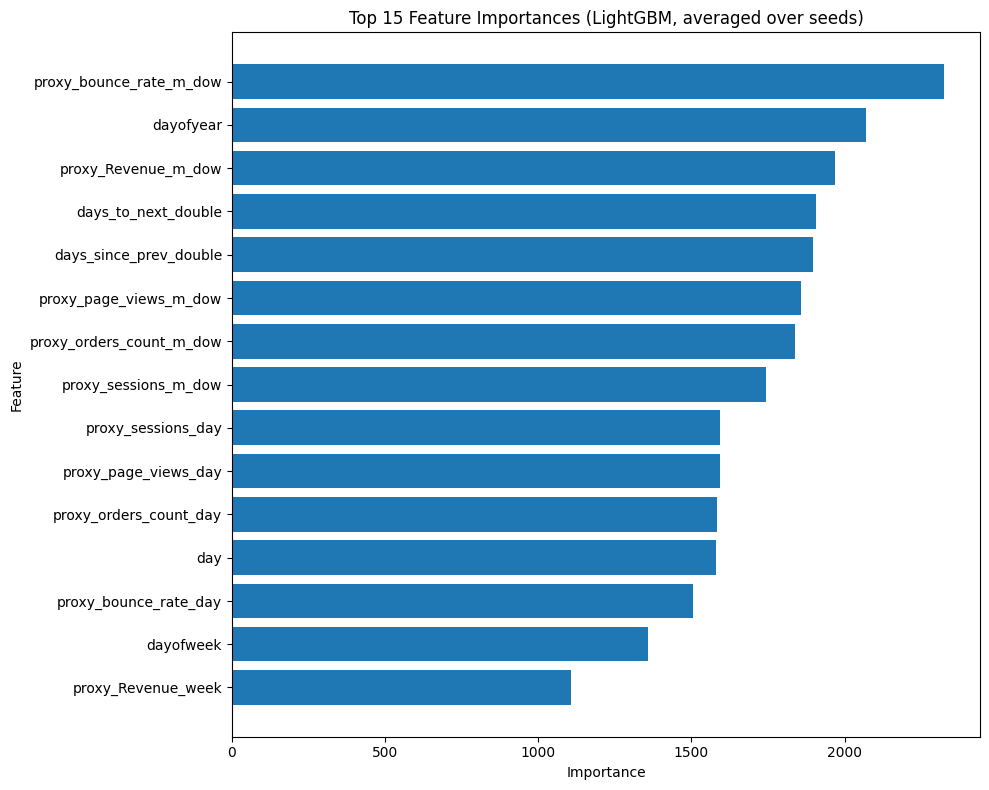


TOP 15 FEATURES THEO SHAP
                 feature  mean_abs_shap
      proxy_Revenue_week  755722.907960
  proxy_orders_count_day  297518.513879
                     day  142127.575765
       proxy_Revenue_day  138557.566015
proxy_orders_count_m_dow  128982.226550
 proxy_orders_count_week  123838.120154
  proxy_page_views_m_dow  122215.115457
    proxy_sessions_m_dow  106688.464343
     proxy_sessions_week  106029.774392
     proxy_Revenue_m_dow  104542.586473
  days_since_prev_double  102882.643039
     days_to_next_double   79405.722414
 proxy_bounce_rate_m_dow   68345.640110
               dayofyear   53607.288274
              weekofyear   49144.646943


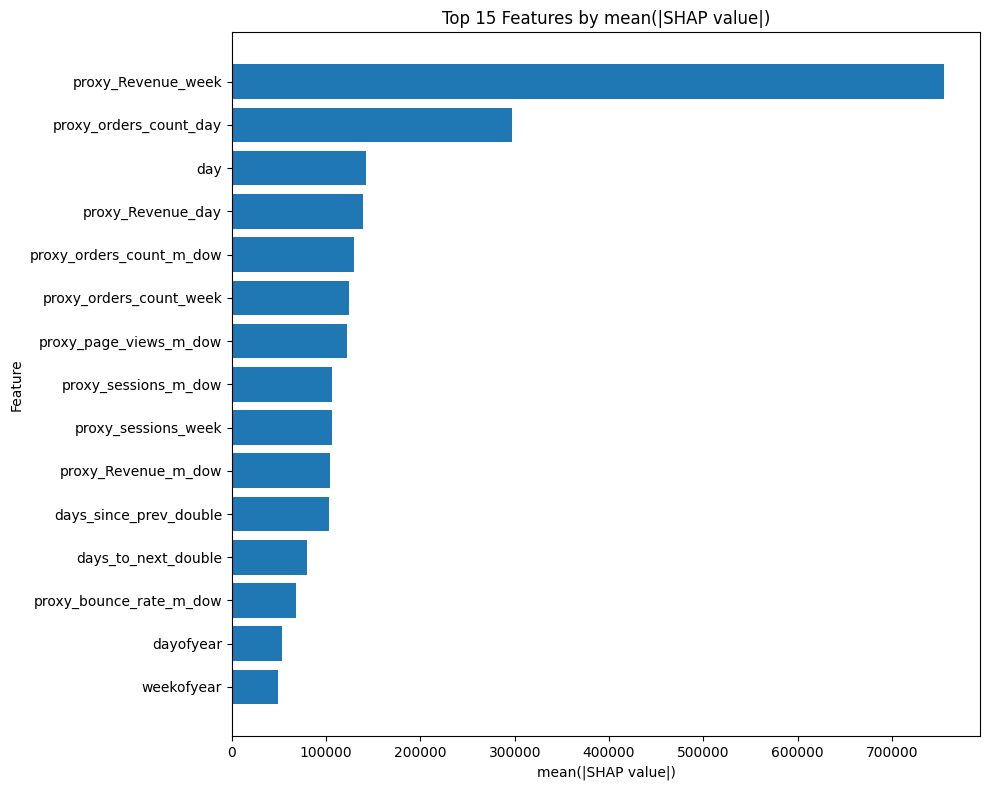

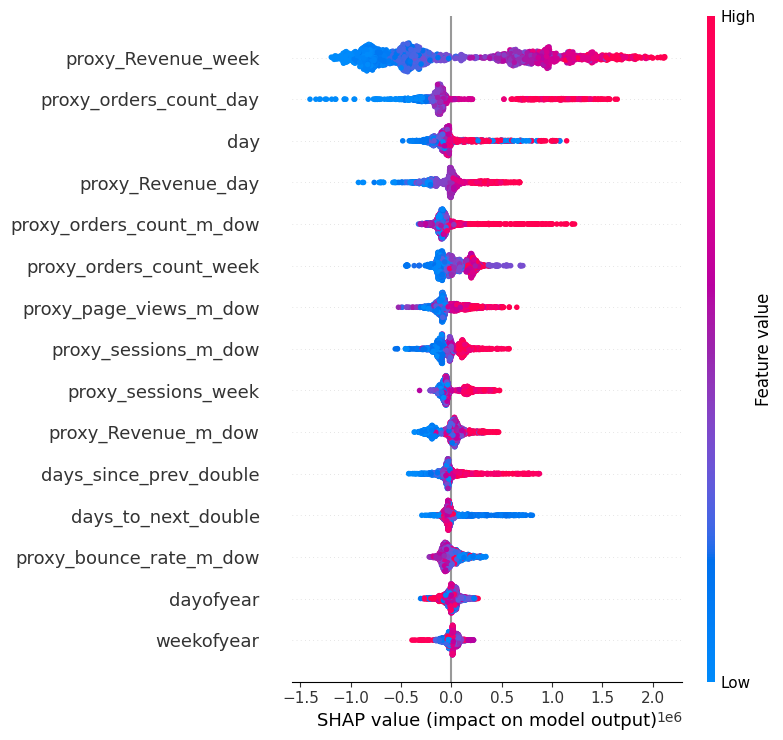

In [8]:
# =========================================
# 5.2 EXPLAINABILITY: FEATURE IMPORTANCE + SHAP
# =========================================
import matplotlib.pyplot as plt

# -------------------------------------------------
# A. Feature importance từ LightGBM (trung bình nhiều seed)
# -------------------------------------------------
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': lgb_importance
}).sort_values('importance', ascending=False)

print("\nTOP 15 FEATURES THEO LIGHTGBM FEATURE IMPORTANCE")
print(feature_importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top_n = 15
plt.barh(feature_importance_df.head(top_n)['feature'][::-1],
         feature_importance_df.head(top_n)['importance'][::-1])
plt.title('Top 15 Feature Importances (LightGBM, averaged over seeds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# B. SHAP trên một mô hình LightGBM đại diện
#    (dùng train full tới 2022 để giải thích mô hình cuối)
# -------------------------------------------------
try:
    import shap

    # Huấn luyện một mô hình đại diện để giải thích
    shap_model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=800,
        learning_rate=0.012,
        max_depth=7,
        num_leaves=45,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    shap_model.fit(X_full, y_full)

    # Lấy mẫu để SHAP chạy nhẹ hơn
    X_shap_sample = X_full.sample(min(2000, len(X_full)), random_state=42)

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap_sample)

    # Bảng SHAP mean(|value|)
    shap_importance = pd.DataFrame({
        'feature': X_shap_sample.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    print("\nTOP 15 FEATURES THEO SHAP")
    print(shap_importance.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    plt.barh(shap_importance.head(top_n)['feature'][::-1],
             shap_importance.head(top_n)['mean_abs_shap'][::-1])
    plt.title('Top 15 Features by mean(|SHAP value|)')
    plt.xlabel('mean(|SHAP value|)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    # SHAP summary plot
    shap.summary_plot(shap_values, X_shap_sample, max_display=15)

except Exception as e:
    print(f"SHAP could not be computed: {e}")

## Key Drivers của Doanh thu (Feature Importance & SHAP)

Kết quả từ Feature Importance và SHAP cho thấy 4 nhóm yếu tố chính:

---

### (1) Seasonality & Calendar – “Thời điểm quyết định doanh thu”

**Biến chính:**
`month, dayofweek, weekofyear, is_double_day, is_payday`

**Insight:**

* Doanh thu biến động mạnh theo **chu kỳ thời gian**
* Tăng cao vào:

  * Cuối tuần
  * Ngày sale lớn (11.11, 12.12)
  * Payday (1, 5, 15, 25)

-> Tập trung marketing & flash sale đúng thời điểm để tối đa hóa conversion

---

### (2) Traffic & Engagement – “Traffic tạo doanh thu”

**Biến chính:**
`proxy_sessions_*, proxy_page_views_*, proxy_orders_count_*, bounce_rate`

**Insight:**

* Traffic cao → tăng doanh thu
* Nhưng:

  * Bounce rate cao → giảm hiệu quả
  * Conversion mới là yếu tố quyết định

-> Tối ưu UX/UI, chất lượng traffic thay vì chỉ tăng số lượng

---

### (3) Historical Behavior – “Hành vi lặp lại”

**Biến chính:**
`proxy_*_m_dow, proxy_*_day, proxy_*_week`

**Insight:**

* Doanh thu có **pattern lặp lại theo tuần/tháng**
* Model học được “memory” từ lịch sử gần

-> Xây dựng campaign định kỳ (weekly, payday, seasonal)

---

### (4) Proxy Revenue – “Baseline doanh thu”

**Biến chính:**
`proxy_Revenue_*`

**Insight:**

* Là feature quan trọng nhất (theo SHAP)
* Đóng vai trò **neo dự báo vào mức lịch sử**

-> Doanh thu có tính ổn định, dễ dự báo nếu không có biến động lớn

---

## Tổng hợp Insight Kinh doanh

* **Right Time > Everything** → Thời điểm quyết định doanh thu
* **Traffic ≠ Revenue** → Chất lượng traffic quan trọng hơn số lượng
* **History repeats** → Có thể khai thác pattern chu kỳ
* **Predictable business** → Doanh thu ổn định nếu không có shock

---

## Kết luận Explainability

* Model **không phải black-box**
* SHAP + Feature Importance giúp:

  * Giải thích dự báo
  * Chuyển thành insight kinh doanh
* Các yếu tố học được **phù hợp thực tế e-commerce thời trang** → tăng độ tin cậy triển khai 


## 9. Final Prediction

In [9]:
# =========================================
# 6. DỰ BÁO TẬP TEST VÀ XUẤT SUBMISSION
# =========================================
pred_test_final = (preds_test_lgb * 0.40) + (preds_test_xgb * 0.20) + (preds_test_cb * 0.40)

submission = test_df[['Date']].copy()
submission['Revenue'] = pred_test_final

margin_map = df[recent_train_mask].groupby('month').apply(
    lambda x: (x['COGS'] / x['Revenue'].replace(0, np.nan)).median()
).to_dict()
global_margin = (df[recent_train_mask]['COGS'] / df[recent_train_mask]['Revenue'].replace(0, np.nan)).median()

submission['month'] = submission['Date'].dt.month
submission['COGS'] = submission['Revenue'] * submission['month'].map(margin_map).fillna(global_margin)

submission['Revenue'] = submission['Revenue'].clip(lower=0)
submission['COGS'] = submission['COGS'].clip(lower=0)
submission.drop(columns=['month'], inplace=True)

submission = submission[['Date', 'Revenue', 'COGS']]
submission.to_csv("submission.csv", index=False)

print("\nHoàn tất xuất file submission.csv")


Hoàn tất xuất file submission.csv


## 10. Conclusion

### Final Insight

Doanh thu phụ thuộc vào:
- thời điểm
- traffic
- hành vi lịch sử  

Có thể áp dụng trực tiếp vào business strategy